<a href="https://colab.research.google.com/github/chomingi-25/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  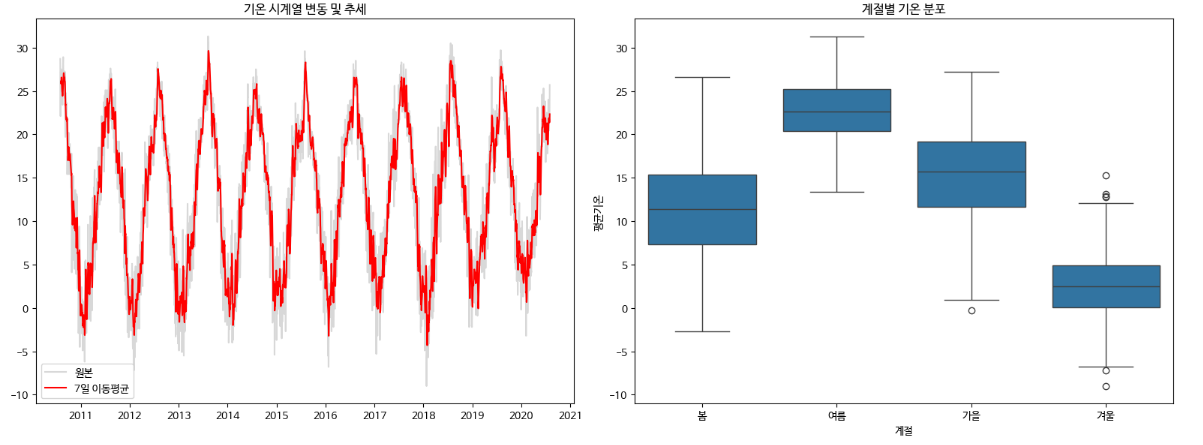

  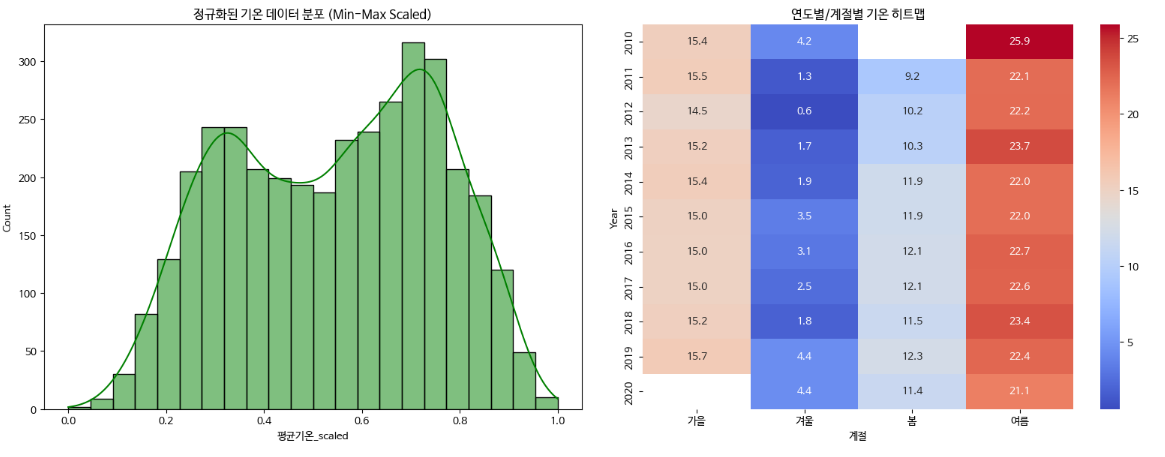



In [ ]:
# 1. 한글 라이브러리 및 폰트 설치
!pip install --upgrade -q koreanize-matplotlib
!sudo apt-get install -y fonts-nanum

# 2. 폰트 캐시 및 Matplotlib 설정 완전 삭제 (가장 중요)
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetyp

✅ 한글 폰트 설정 완료


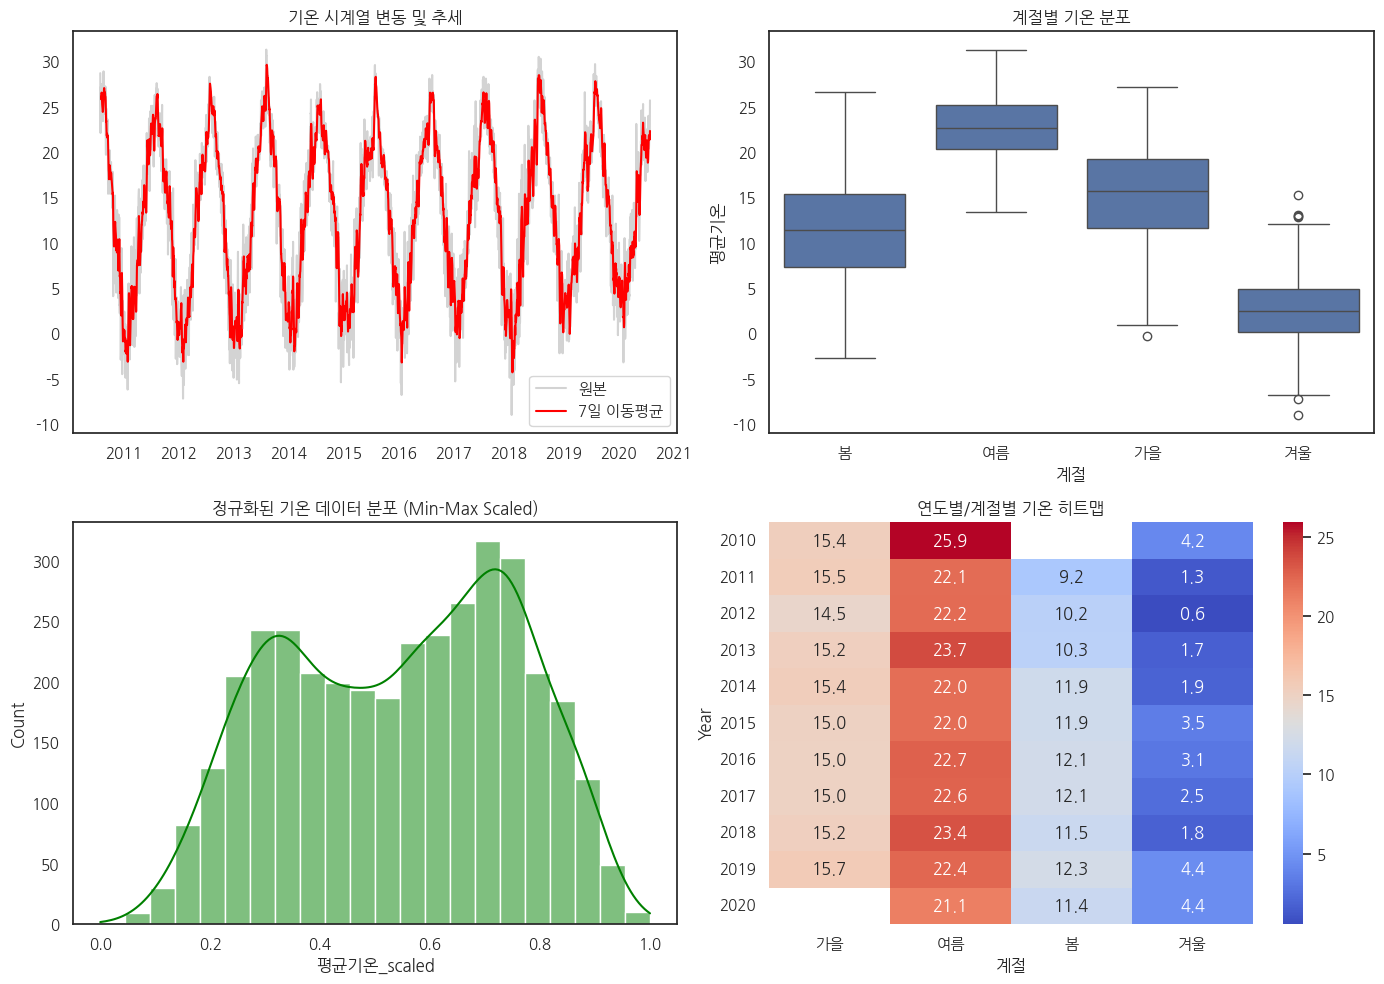

In [ ]:
# 20251461 조민기

import koreanize_matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
import requests
import warnings
warnings.filterwarnings('ignore')

#-------------------------------------------------------
# 0. 배경색 설정
#-------------------------------------------------------
def set_background_color():
  sns.set(style='white')

#-------------------------------------------------------
# 1. 한글 폰트 설정
#-------------------------------------------------------
def setup_korean_font():
  os.system('apt-get -qq install fonts-nanum')
  os.system('rm -rf ~/.cache/matplotlib')
  plt.rc('font', family='NanumGothic')
  plt.rcParams['axes.unicode_minus']=False
  print("✅ 한글 폰트 설정 완료")

#-------------------------------------------------------
# 2. CSV 불러오기
#-------------------------------------------------------
def load_weather_data(file_name):
  df=pd.read_csv(file_name, encoding='cp949')
  return df

#-------------------------------------------------------
# 3. Min-Max Scaling 함수
#-------------------------------------------------------

def min_max_scale(series):
  if series.min()==series.max():
    return series
  return (series-series.min())/(series.max()-series.min())

#-------------------------------------------------------
# 4. 계절 분류 함수
#-------------------------------------------------------
def get_season(month):
  if month in [3, 4, 5]:
    return '봄'
  elif month in [6, 7, 8]:
    return '여름'
  elif month in [9, 10, 11]:
    return '가을'
  elif month==12 or 1<=month<=2:
    return '겨울'

#-------------------------------------------------------
# 5. 데이터 전처리 함수(시계열 핸들링)
#-------------------------------------------------------
def preprocess_data(df):
  df['일시']=pd.to_datetime(df['일시'])
  df=df.set_index('일시')
  num_cols=['평균기온', '최대풍속', '평균풍속']
  df[num_cols]=df[num_cols].interpolate()
  df['연도']=df.index.year
  df['월']=df.index.month
  df['계절']=df['월'].apply(get_season)
  df['평균기온_scaled']=min_max_scale(df['평균기온'])
  df['평균기온_7일이동평균']=df['평균기온'].rolling(window=7).mean()
  return df
#--------------------------------------------------------
# 6. (1) 계절별 통계 - groupby()
#--------------------------------------------------------
def seasonal_statistics(df):
  season_order=['봄', '여름', '가을', '겨울']
  seasonal_stats=df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].agg(['mean', 'max', 'min'])
  seasonal_stats=seasonal_stats.reindex(season_order)
  return seasonal_stats

#--------------------------------------------------------
# 6. (2) 연도별/계절별 통계 -2) pivot_table()
#--------------------------------------------------------
def yearly_season_pivot(df):
  season_order=['봄', '여름', '가을', '겨울']
  pivot=pd.pivot_table(df, values='평균기온', index='연도', columns='계절',
                       aggfunc='mean')
  pivot=pivot.reindex(columns=season_order)
  return pivot

#--------------------------------------------------------
# 7. 그래프 그리기
#--------------------------------------------------------
def set_graph_style(df, pivot):
  fig, ax=plt.subplots(2, 2, figsize=(14, 10))
  pivot=yearly_season_pivot(df)
  plot_time_series(ax[0][0], df)
  plot_season(ax[0][1], df)
  plot_scaled_histogram(ax[1][0], df)
  plot_heatmap(ax[1][1], pivot)
  for a in ax.flatten():
    a.grid(False)
  plt.tight_layout()
  plt.show()

# (1) 시계열 데이터
def plot_time_series(ax, df):
  ax.plot(df.index, df['평균기온'], color='lightgray', label='원본')
  ax.plot(df.index, df['평균기온_7일이동평균'], color='red',
           label='7일 이동평균')
  ax.set_title('기온 시계열 변동 및 추세')
  ax.legend()

# (2) 계절별 기온을 boxplot() 함수로 표현
def plot_season(ax, df):
  season_order=['봄', '여름', '가을', '겨울']
  sns.boxplot(data=df, x='계절', y='평균기온', order=season_order, ax=ax)
  ax.set_title("계절별 기온 분포")
  ax.set_xlabel('계절')
  ax.set_ylabel('평균기온')

# (3) 정규화된 기온 데이터 히스토그램
def plot_scaled_histogram(ax, df):
  sns.histplot(df['평균기온_scaled'], bins=22, kde=True, kde_kws={'cut':0}, color='green', ax=ax)
  ax.set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
  ax.set_xlabel('평균기온_scaled')
  ax.set_ylabel('Count')

# (4) 연도 및 계절별 기온 히트맵
def plot_heatmap(ax, pivot):
  season_order=['가을', '여름', '봄', '겨울']
  pivot=pivot.reindex(columns=season_order)
  sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm', ax=ax)
  ax.set_title('연도별/계절별 기온 히트맵')
  ax.set_xlabel('계절')
  ax.set_ylabel('Year')

#--------------------------------------------------------
# 8. 엑셀 파일 저장
#--------------------------------------------------------
def save_to_excel(df, seasonal_stats, pivot):
  with pd.ExcelWriter('weather_analysis_resport.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='전처리데이터')
    seasonal_stats.to_excel(writer, sheet_name='계절별통계')
    pivot.to_excel(writer, sheet_name='연도별피벗테이블')


#----------------------------------------------------
# 9. main()
#----------------------------------------------------
def main():
  set_background_color()
  setup_korean_font()

  data_url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
  file_name = 'weather.csv'

  # Download the file if it doesn't exist
  if not os.path.exists(file_name):
    print(f"Downloading {file_name} from {data_url}...")
    try:
      response = requests.get(data_url)
      response.raise_for_status() # Raise an exception for bad status codes
      with open(file_name, 'wb') as f:
        f.write(response.content)
      print(f"✅ {file_name} downloaded successfully.")
    except requests.exceptions.RequestException as e:
      print(f"Error downloading the file: {e}")
      return # Exit if download fails

  df=load_weather_data(file_name)
  df=preprocess_data(df)
  df_scale=min_max_scale(df['평균기온'])
  seasonal_stats=seasonal_statistics(df)
  pivot=yearly_season_pivot(df)
  set_graph_style(df, pivot)
  save_to_excel(df, seasonal_stats, pivot)

#----------------------------------------------------
# 10. 프로그램 시작
#----------------------------------------------------
if __name__=='__main__':
  main()

# 위의 코드는 쳇 지피티 및 제미나이,
# 한글 폰트 설정 코드의 도움을 받아 작성되었으며,
# 쳇 지피티의 코드 및 주석에서 주석 및 표현을 변형시켰음을 알립니다.
# 출처 : 쳇 지피티, 제미나이